In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb

# Load dataset (file should be in the same folder as notebook)
df = pd.read_csv("retail_sales_data.csv")



In [3]:
!pip install xgboost

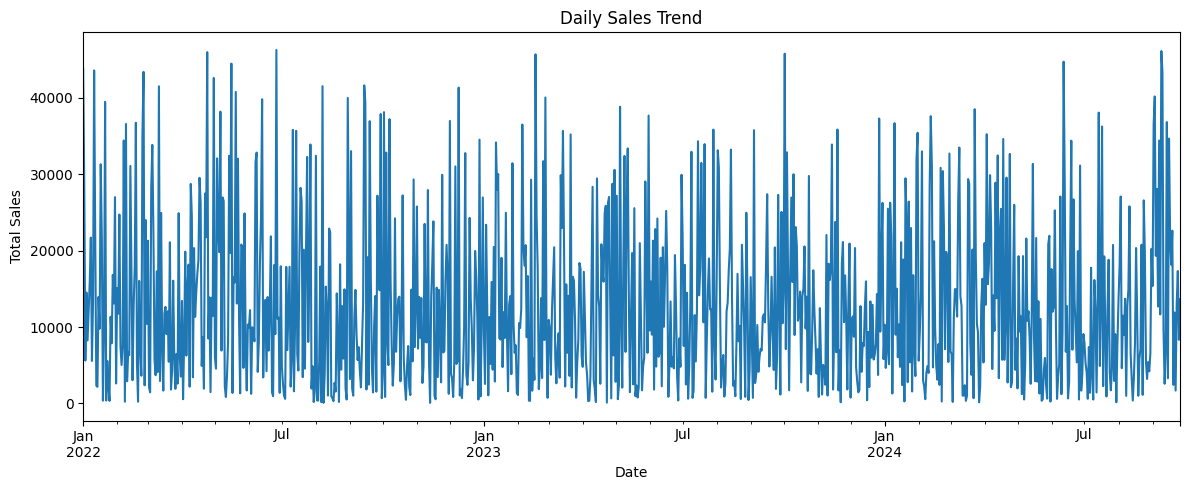

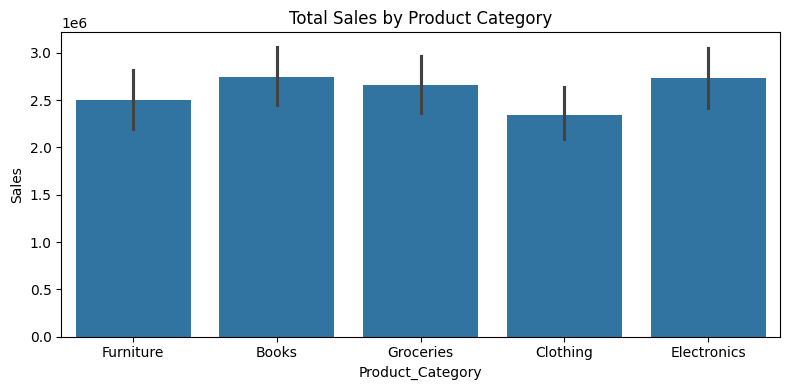

In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Year'] = df['Date'].dt.year

# Daily Sales Trend
plt.figure(figsize=(12, 5))
df.groupby('Date')['Sales'].sum().plot()
plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

# Sales by Product Category
plt.figure(figsize=(8, 4))
sns.barplot(x='Product_Category', y='Sales', data=df, estimator=np.sum)
plt.title('Total Sales by Product Category')
plt.tight_layout()
plt.show()



In [5]:
le = LabelEncoder()
df['Product_Category'] = le.fit_transform(df['Product_Category'])
df['Region'] = le.fit_transform(df['Region'])
df['Customer_Segment'] = le.fit_transform(df['Customer_Segment'])

features = ['Product_Category', 'Region', 'Customer_Segment', 'Units_Sold', 'Unit_Price', 'Month', 'DayOfWeek', 'Year']
X = df[features]
y = df['Sales']


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)


In [7]:
def evaluate_model(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name} Model - MAE: {mae:.2f}, RMSE: {rmse:.2f}")

evaluate_model(y_test, y_pred_rf, "Random Forest")
evaluate_model(y_test, y_pred_xgb, "XGBoost")


Random Forest Model - MAE: 383.20, RMSE: 554.00
XGBoost Model - MAE: 322.58, RMSE: 496.20


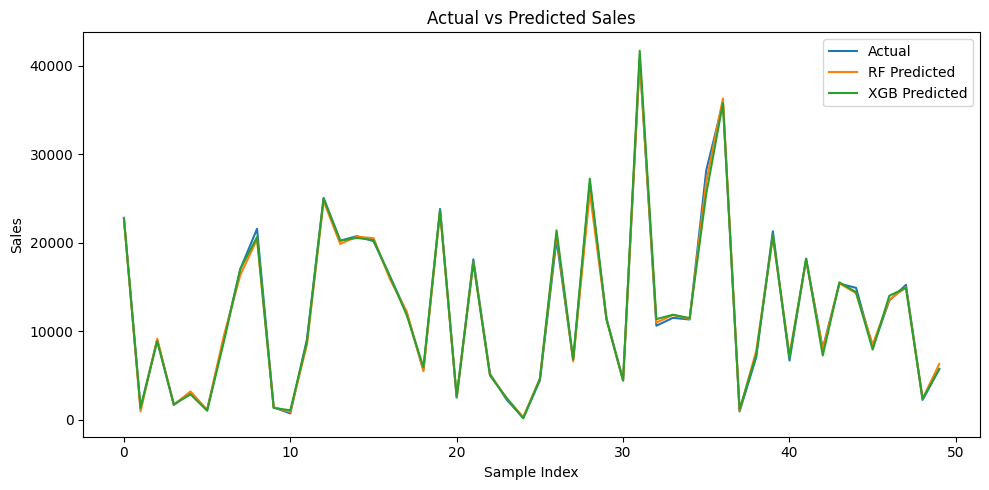

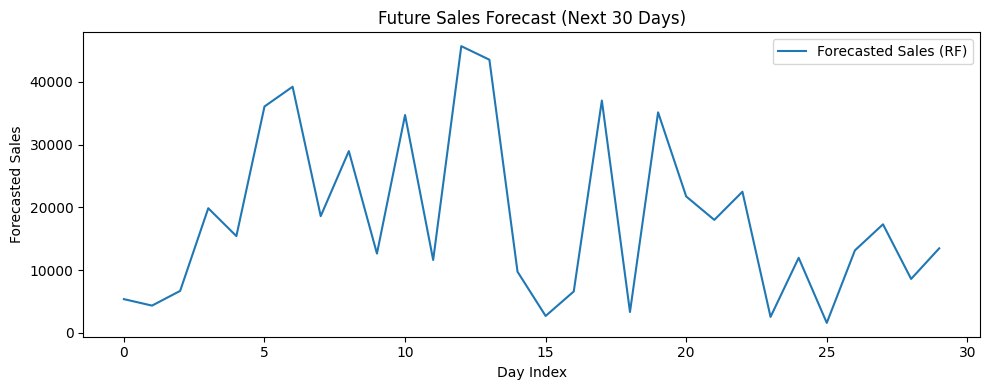

In [8]:
# Actual vs Predicted
plt.figure(figsize=(10, 5))
plt.plot(y_test.values[:50], label='Actual')
plt.plot(y_pred_rf[:50], label='RF Predicted')
plt.plot(y_pred_xgb[:50], label='XGB Predicted')
plt.title('Actual vs Predicted Sales')
plt.xlabel('Sample Index')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

# Future Sales Forecast (last 30 days)
future_data = X.tail(30)
future_preds_rf = rf_model.predict(future_data)

plt.figure(figsize=(10, 4))
plt.plot(range(len(future_preds_rf)), future_preds_rf, label='Forecasted Sales (RF)')
plt.title('Future Sales Forecast (Next 30 Days)')
plt.xlabel('Day Index')
plt.ylabel('Forecasted Sales')
plt.legend()
plt.tight_layout()
plt.show()
